In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# Load Dataset
df = pd.read_excel("Online-Store-Orders.xlsx")

In [5]:
# Basic Information
print(df.shape)
print(df.info())
print(df.isnull().sum())


(1200, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64

In [6]:
df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

In [7]:
print(df.isnull().sum())

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64


In [8]:
numeric_cols = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, "Outliers:", len(outliers))

Quantity Outliers: 0
UnitPrice Outliers: 0
ItemsInCart Outliers: 0
TotalPrice Outliers: 8


In [9]:
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["TotalPrice"] = df["TotalPrice"].clip(lower, upper)

In [10]:
df["Month"] = df["Date"].dt.month

df["DayOfWeek"] = df["Date"].dt.day_name()

df["HasCoupon"] = (
    df["CouponCode"] != "No Coupon"
).astype(int)

In [11]:
df[["Month","DayOfWeek","HasCoupon"]].head()

,Month,DayOfWeek,HasCoupon
0,1,Wednesday,1
1,8,Friday,1
2,2,Tuesday,1
3,10,Sunday,1
4,5,Thursday,1


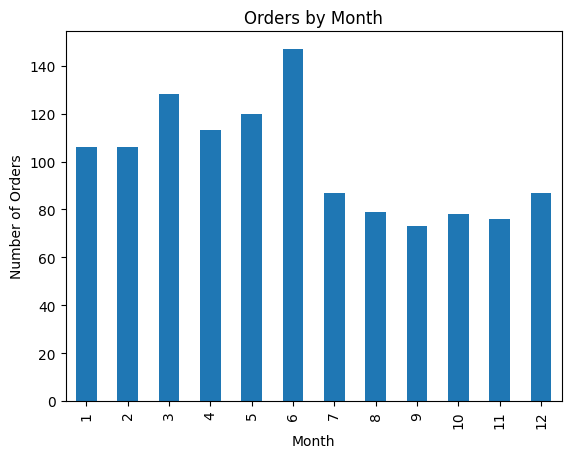

In [18]:
#Feature 1: Month
df["Month"].value_counts().sort_index().plot(kind="bar")
plt.title("Orders by Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.show()

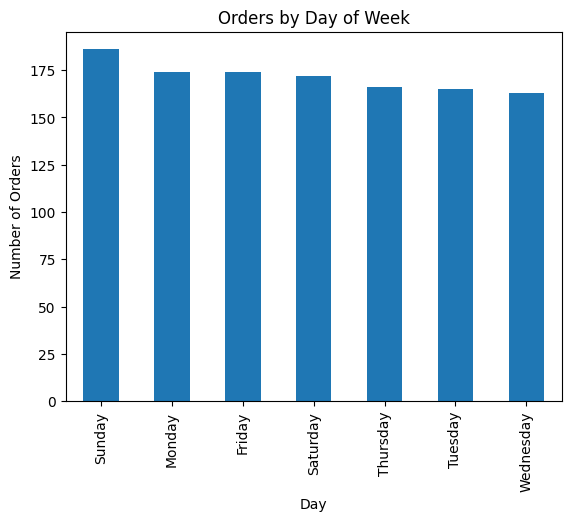

In [19]:
#Feature 2: DayOfWeek
df["DayOfWeek"].value_counts().plot(kind="bar")
plt.title("Orders by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Orders")
plt.show()

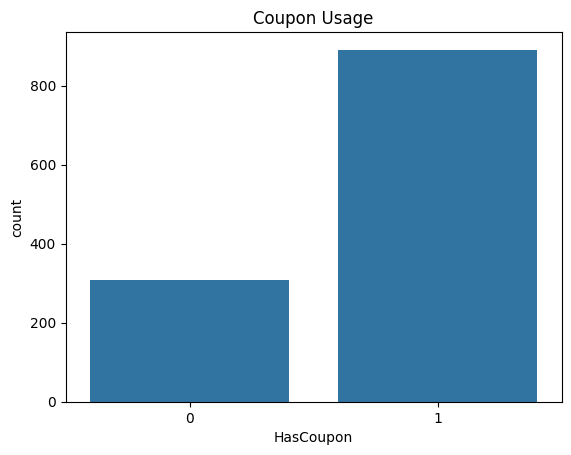

In [20]:
sns.countplot(data=df, x="HasCoupon")
plt.title("Coupon Usage")
plt.show()

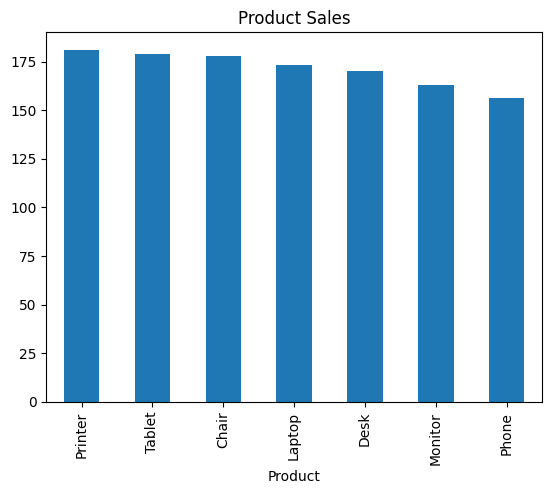

In [12]:
df["Product"].value_counts().plot(kind="bar")
plt.title("Product Sales")
plt.show()

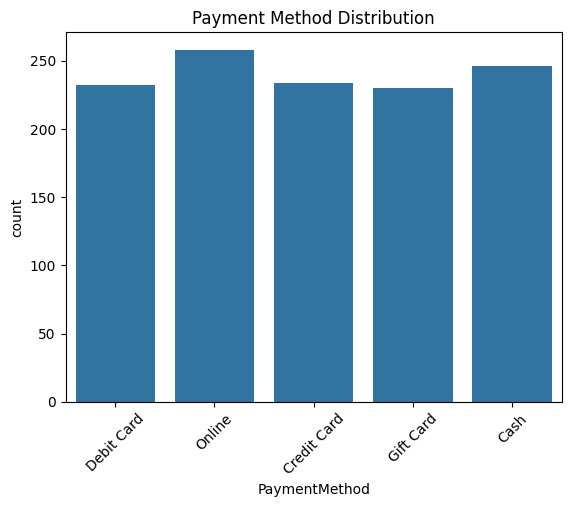

In [13]:
sns.countplot(data=df, x="PaymentMethod")
plt.xticks(rotation=45)
plt.title("Payment Method Distribution")
plt.show()

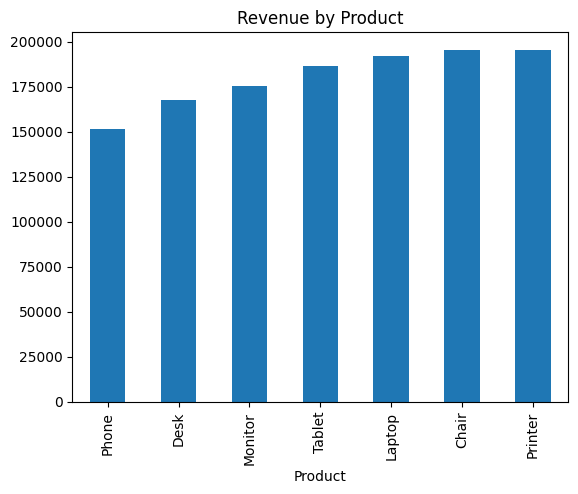

In [14]:
df.groupby("Product")["TotalPrice"].sum().sort_values().plot(kind="bar")
plt.title("Revenue by Product")
plt.show()

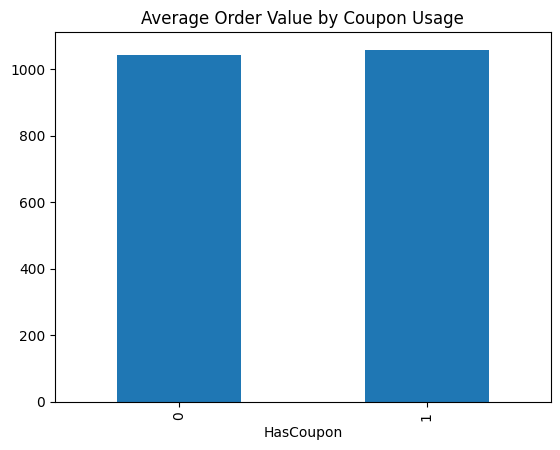

In [21]:
df.groupby("HasCoupon")["TotalPrice"].mean().plot(kind="bar")
plt.title("Average Order Value by Coupon Usage")
plt.show()

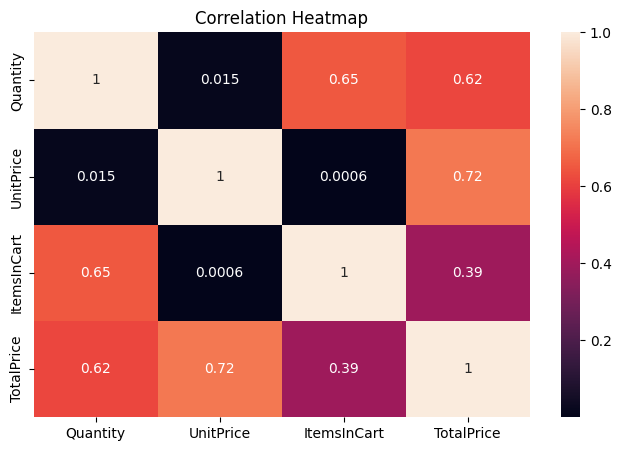

In [17]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[["Quantity","UnitPrice","ItemsInCart","TotalPrice"]].corr(),
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()